In [1]:
# Graph Construction Sanity Check
# This notebook copies the graph construction logic from main.py,
# builds the graph from training windows, checks disconnected components,
# and visualizes the graph.

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "data").exists():
    repo_root = repo_root.parent
if not (repo_root / "data").exists():
    raise FileNotFoundError("Could not locate repository root containing data/ directory.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from data.rbc_dataset import make_dataloaders

In [5]:
def collect_node_features(loader, max_batches):
    """Collect node-wise time features from context windows.

    Returns:
        features: (N, S) where S is concatenated samples over batch/time.
    """
    chunks = []

    for batch_idx, batch in enumerate(loader):
        if batch_idx >= max_batches:
            break

        x_ctx = batch["x"].float()  # (B, Lx, N)
        node_series = x_ctx.permute(2, 0, 1).reshape(x_ctx.shape[-1], -1)  # (N, B*Lx)
        chunks.append(node_series)

    if not chunks:
        raise RuntimeError("Unable to build graph: train loader produced zero batches.")

    features = torch.cat(chunks, dim=1)  # (N, S)
    features = (features - features.mean(dim=1, keepdim=True)) / (
        features.std(dim=1, keepdim=True) + 1e-6
    )
    return features


def build_gaussian_knn_graph(loader, max_batches, k, sigma):
    """Build an undirected kNN graph from Gaussian-kernel node similarities."""
    features = collect_node_features(loader, max_batches=max_batches)  # (N, S)
    num_nodes = features.shape[0]

    if num_nodes < 2:
        raise ValueError(f"Need at least 2 nodes, got {num_nodes}")
    if k <= 0 or k >= num_nodes:
        raise ValueError(f"k must be in [1, N-1], got k={k}, N={num_nodes}")

    dist = torch.cdist(features, features, p=2)  # (N, N)
    dist2 = dist.pow(2)

    if sigma is None:
        mask = ~torch.eye(num_nodes, dtype=torch.bool)
        sigma_val = float(torch.sqrt(dist2[mask].median() + 1e-12).item())
    else:
        sigma_val = float(sigma)
    if sigma_val <= 0:
        raise ValueError(f"sigma must be positive, got {sigma_val}")

    kernel = torch.exp(-dist2 / (2.0 * sigma_val * sigma_val))  # (N, N)

    neighborhood = torch.zeros((num_nodes, num_nodes), dtype=torch.bool)
    for dst in range(num_nodes):
        row = kernel[dst].clone()
        row[dst] = -1.0
        nn_idx = torch.topk(row, k=k, largest=True).indices
        neighborhood[dst, nn_idx] = True

    neighborhood = neighborhood | neighborhood.T
    neighborhood.fill_diagonal_(False)

    dst_idx, src_idx = torch.where(neighborhood)
    edge_index = torch.stack([src_idx, dst_idx], dim=0).long()
    return edge_index, kernel, sigma_val

In [7]:
# Keep these aligned with main.py defaults unless you want to experiment.
manifest_csv = repo_root / "data" / "manifest.csv"
cohort = None
x = 30
y = 10
stride = 10
batch_size = 8
num_workers = 2
min_t = 0
cache = False
k = 5
sigma = None
max_batches = 8

loaders = make_dataloaders(
    manifest_csv=manifest_csv,
    x=x,
    y=y,
    stride=stride,
    batch_size=batch_size,
    num_workers=num_workers,
    cohort=cohort,
    min_t=min_t,
    cache=cache,
)
train_loader = loaders["train"]

edge_index, kernel, sigma_val = build_gaussian_knn_graph(
    loader=train_loader,
    max_batches=max_batches,
    k=k,
    sigma=sigma,
)

num_nodes = int(kernel.shape[0])
num_undirected_edges = int(edge_index.shape[1] // 2)
print(f"nodes={num_nodes}, directed_edges={edge_index.shape[1]}, undirected_edges~={num_undirected_edges}")
print(f"sigma={sigma_val:.6f}")

RBCDataset(split='train', x=30, y=10, stride=10) | 46355 windows from 2035 runs
RBCDataset(split='val', x=30, y=10, stride=10) | 10103 windows from 441 runs
RBCDataset(split='test', x=30, y=10, stride=10) | 9806 windows from 432 runs
RBCDataset(split='within', x=30, y=10, stride=10) | 2908 windows from 2908 runs
nodes=400, directed_edges=2656, undirected_edges~=1328
sigma=62.194492


In [8]:
def connected_components_from_edge_index(num_nodes, edge_index):
    adjacency = [set() for _ in range(num_nodes)]
    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()

    for u, v in zip(src, dst):
        if u != v:
            adjacency[u].add(v)
            adjacency[v].add(u)

    components = []
    seen = [False] * num_nodes

    for node in range(num_nodes):
        if seen[node]:
            continue
        stack = [node]
        seen[node] = True
        comp = []

        while stack:
            cur = stack.pop()
            comp.append(cur)
            for nxt in adjacency[cur]:
                if not seen[nxt]:
                    seen[nxt] = True
                    stack.append(nxt)

        components.append(sorted(comp))

    components.sort(key=len, reverse=True)
    return components, adjacency


components, adjacency = connected_components_from_edge_index(num_nodes, edge_index)
print(f"connected_components={len(components)}")
print("component_sizes=", [len(c) for c in components])

if len(components) == 1:
    print("Graph is connected.")
else:
    print("Graph has disconnected components.")

connected_components=1
component_sizes= [400]
Graph is connected.


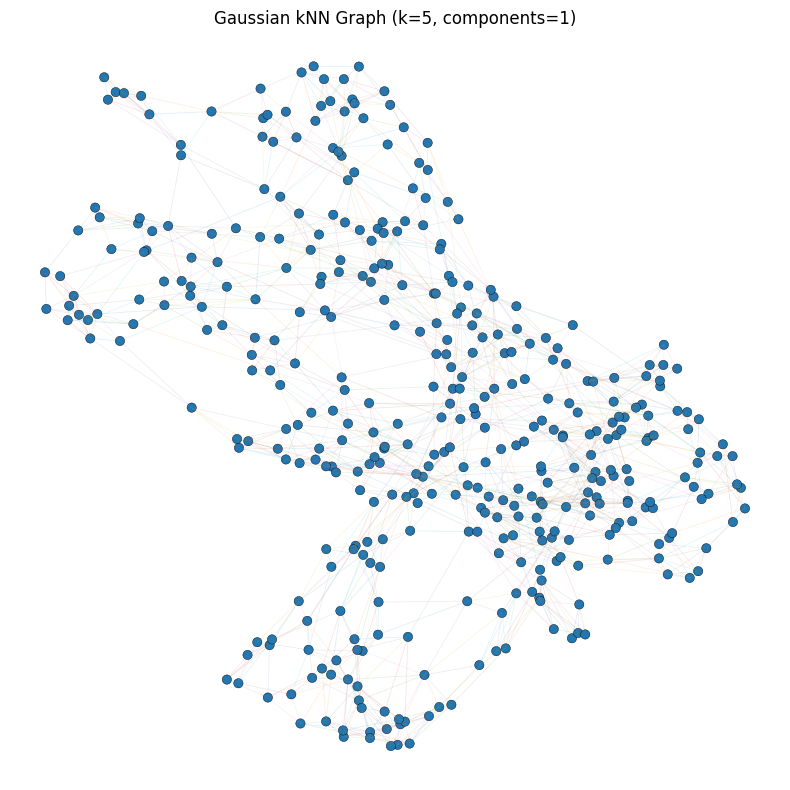

In [9]:
def spring_layout(adjacency, iterations=300, seed=42):
    rng = np.random.default_rng(seed)
    n = len(adjacency)
    pos = rng.normal(0, 1.0, size=(n, 2)).astype(np.float64)
    if n == 1:
        return pos

    area = 1.0
    k = np.sqrt(area / n)
    t = 0.1

    for _ in range(iterations):
        disp = np.zeros_like(pos)

        # Repulsive force
        for i in range(n):
            delta = pos[i] - pos
            dist = np.linalg.norm(delta, axis=1) + 1e-9
            dist[i] = 1e9
            rep = (k * k / dist[:, None]) * (delta / dist[:, None])
            disp[i] += rep.sum(axis=0)

        # Attractive force
        for i in range(n):
            for j in adjacency[i]:
                if j <= i:
                    continue
                delta = pos[i] - pos[j]
                dist = np.linalg.norm(delta) + 1e-9
                force = (dist * dist / k) * (delta / dist)
                disp[i] -= force
                disp[j] += force

        norms = np.linalg.norm(disp, axis=1) + 1e-9
        step = np.minimum(norms, t)[:, None] * (disp / norms[:, None])
        pos += step
        t *= 0.995

    pos -= pos.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(pos, axis=1)) + 1e-9
    pos /= scale
    return pos


pos = spring_layout(adjacency, iterations=250, seed=42)

plt.figure(figsize=(8, 8))
for u in range(num_nodes):
    for v in adjacency[u]:
        if v > u:
            plt.plot([pos[u, 0], pos[v, 0]], [pos[u, 1], pos[v, 1]], alpha=0.12, linewidth=0.6)

component_index = np.zeros(num_nodes, dtype=int)
for idx, comp in enumerate(components):
    component_index[np.array(comp, dtype=int)] = idx

plt.scatter(pos[:, 0], pos[:, 1], c=component_index, s=45, cmap="tab20", edgecolors="black", linewidths=0.3)
plt.title(f"Gaussian kNN Graph (k={k}, components={len(components)})")
plt.axis("off")
plt.tight_layout()
plt.show()